# Exploratory Data Analysis. Training, exportation and quantization of the model

### Ricard Renalias Zueras and Pedro Matheus Figueredo Cristaldo
------------------------------------------------------

First of all, we export the libraries that will be necessaries in this part of the project.

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


## Exploratory Data Analysis and Preprocessing

The training data collected with the ESP32 is stored in the file Lab2DataSet.txt. Let's import it and see its structre:

In [3]:
data = pd.read_csv('Lab2DataSet.txt', sep='\t')
print(data.head())
print('\n')
print(data.tail())

   SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX   gyroY  \
0           0          0        0   -0.28   -0.50   -1.17 -28.10   57.85   
1           0          0        1   -0.27   -0.38   -1.08 -21.85   91.79   
2           0          0        2   -0.22   -0.28   -0.97 -31.23  110.73   
3           0          0        3   -0.19   -0.14   -0.94 -54.73  118.67   
4           0          0        4   -0.18   -0.08   -0.97 -51.85  120.98   

   gyroZ  
0 -35.08  
1 -45.95  
2 -41.20  
3 -35.83  
4 -28.70  


      SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX  gyroY  \
2995           1         29       45   -0.39   -0.27   -1.27  47.77 -38.52   
2996           1         29       46   -0.34   -0.29   -1.27  20.02 -11.71   
2997           1         29       47   -0.25   -0.18   -1.20 -32.10 -21.02   
2998           1         29       48   -0.28   -0.17   -1.13 -32.91 -29.27   
2999           1         29       49   -0.30   -0.19   -1.04 -21.79 -26.15   

      

Some things to comment about the data. We have six features, the ones from the accelerometer (x, y and z) and from the gyroscope (x, y and z). We have collected two types of gestures, so we have two labels (SampleType in the data, 0 or 1). Each gesture (each datapoint) contains 50 meeasures (where each measure is taken each 20 mili seconds); so each gesture is one of 1 second (and each gesture is composed of 300 features: 50 x 6). We have 30 datapoints (total gestures) per label. 

In [4]:
# Create a new column composed of SampleType and NumSample "SampleId"
#format: SampleId_<SampleType>_<NumSample> where Numsample is a 2 digit number with leading zeros if needed
data['SampleId'] = 'SampleId_'+ data['SampleType'].astype(str) + '_' + data['NumSample'].astype(str).str.zfill(2)
print(data.head())
print(data.tail())

   SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX   gyroY  \
0           0          0        0   -0.28   -0.50   -1.17 -28.10   57.85   
1           0          0        1   -0.27   -0.38   -1.08 -21.85   91.79   
2           0          0        2   -0.22   -0.28   -0.97 -31.23  110.73   
3           0          0        3   -0.19   -0.14   -0.94 -54.73  118.67   
4           0          0        4   -0.18   -0.08   -0.97 -51.85  120.98   

   gyroZ       SampleId  
0 -35.08  SampleId_0_00  
1 -45.95  SampleId_0_00  
2 -41.20  SampleId_0_00  
3 -35.83  SampleId_0_00  
4 -28.70  SampleId_0_00  
      SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX  gyroY  \
2995           1         29       45   -0.39   -0.27   -1.27  47.77 -38.52   
2996           1         29       46   -0.34   -0.29   -1.27  20.02 -11.71   
2997           1         29       47   -0.25   -0.18   -1.20 -32.10 -21.02   
2998           1         29       48   -0.28   -0.17   -1.13 -32.91 -29.27 

As we can observe, the SampleId tell us the label of the data, and the measure number (which is part of the gesture: remember, each gesture is composed of 30 measures).

Now we will se some statistical properties of the dataset:

        SampleType    NumSample      numItem       accelX       accelY  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean      0.500000    14.500000    24.500000    -0.328003     0.073373   
std       0.500083     8.656884    14.433275     0.244821     0.334189   
min       0.000000     0.000000     0.000000    -1.040000    -0.700000   
25%       0.000000     7.000000    12.000000    -0.510000    -0.142500   
50%       0.500000    14.500000    24.500000    -0.360000    -0.020000   
75%       1.000000    22.000000    37.000000    -0.160000     0.230000   
max       1.000000    29.000000    49.000000     0.390000     1.040000   

            accelZ        gyroX        gyroY        gyroZ  
count  3000.000000  3000.000000  3000.000000  3000.000000  
mean     -0.597767     0.798380     4.226353    -1.564940  
std       0.711377    58.304769    75.823288   144.684467  
min      -2.170000  -200.160000  -178.330000  -438.390000  
25%      -1.000000   -37.602500  

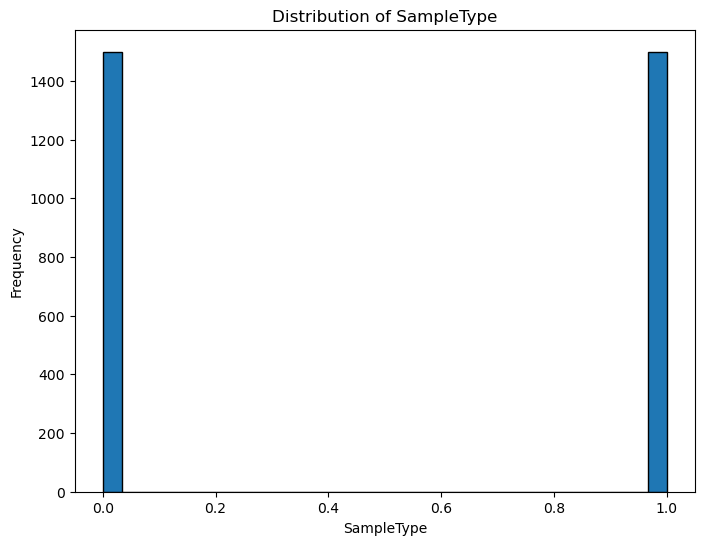

<Figure size 1200x800 with 0 Axes>

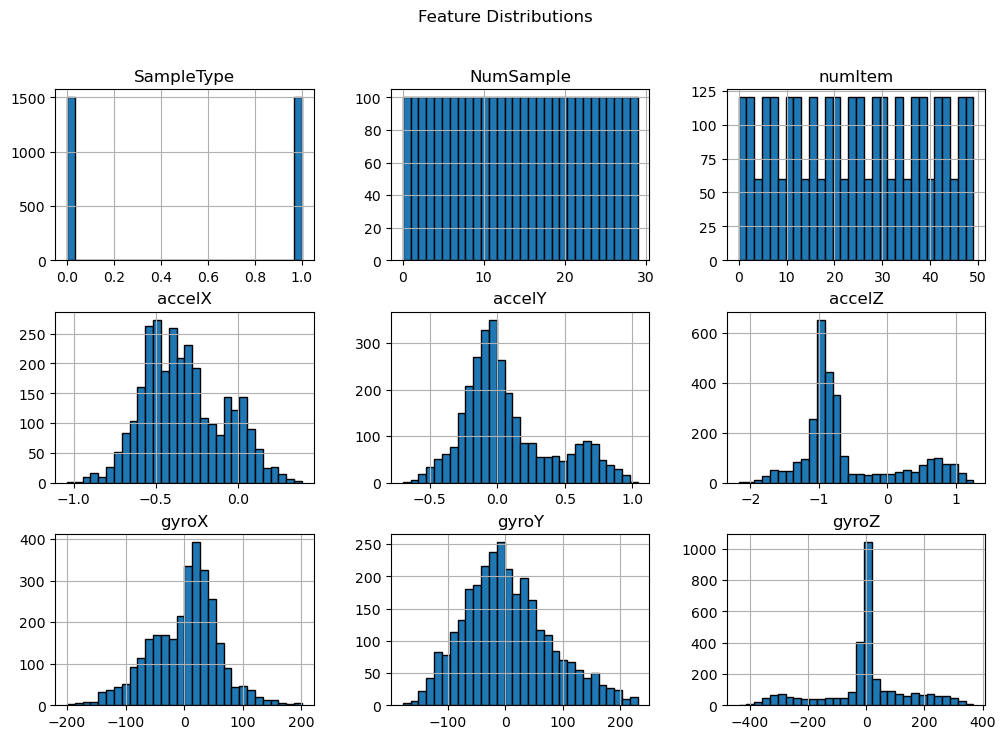

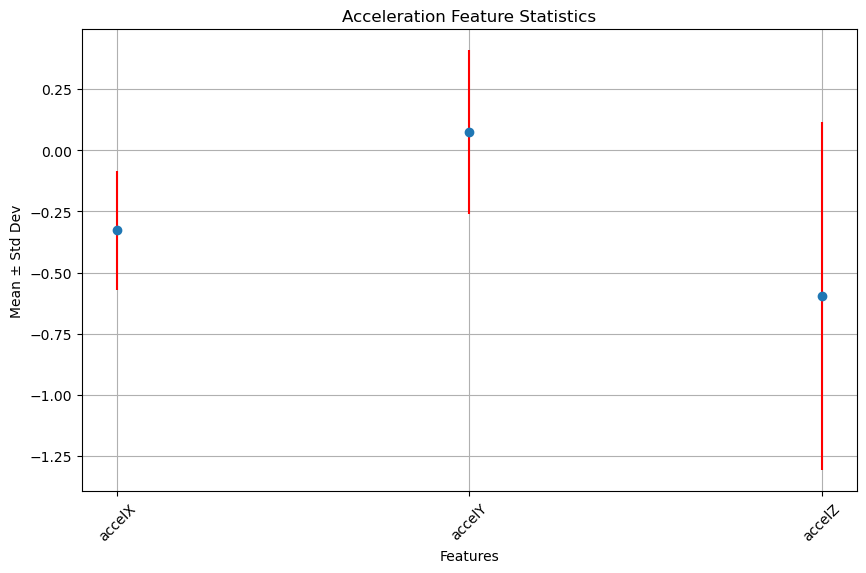

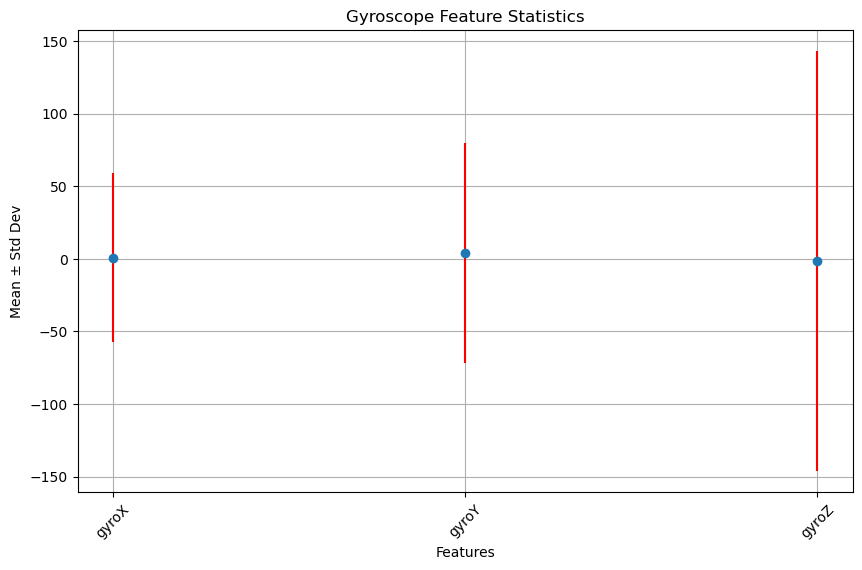

In [5]:
# Exploring statistical properties of the dataset to understand its distribution and characteristics
print(data.describe())

# Visualizing the distribution of the target variable (SampleType)
plt.figure(figsize=(8, 6))
plt.hist(data['SampleType'], bins=30, edgecolor='k')
plt.title('Distribution of SampleType')
plt.xlabel('SampleType')
plt.ylabel('Frequency')
plt.show()

# Visualizing statistical properties of the features
plt.figure(figsize=(12, 8))
data.hist(bins=30, edgecolor='k', figsize=(12, 8))
plt.suptitle('Feature Distributions')
plt.show()

# Plotting data describe results in an error bar char for each feature, except SampleType, NumSample and numItem
# Show acceleration features in one graph and gyroscope features in another graph
features = data.columns.difference(['SampleType', 'NumSample', 'numItem', 'SampleId'])
accel_features = [col for col in features if 'accel' in col]
gyro_features = [col for col in features if 'gyro' in col]
def plot_feature_stats(feature_list, title):
    means = data[feature_list].mean()
    stds = data[feature_list].std()
    
    plt.figure(figsize=(10, 6))
    plt.errorbar(feature_list, means, yerr=stds, fmt='o', ecolor='r', capthick=2)
    plt.title(title)
    plt.xlabel('Features')
    plt.ylabel('Mean ± Std Dev')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()
plot_feature_stats(accel_features, 'Acceleration Feature Statistics')
plot_feature_stats(gyro_features, 'Gyroscope Feature Statistics')


We can observe how the variables (excepting accel z) are approximately centered around zero. Now we are going to compute the mean, std, min and max of each variable. This will help us to perfrom normalization later on.

In [6]:
# Calculate the mean, standard deviation, min, and max of accelX, accelY, accelZ, gyroX, gyroY, gyroZ for the entire dataset
feature_columns = data.columns.difference(['SampleType', 'NumSample', 'numItem', 'SampleId'])
mean_std_min_max = data[feature_columns].agg(['mean', 'std', 'min', 'max'])
print(mean_std_min_max)
# Important to save this table as it must be included in the exported model to be used in ESP32 inference.

        accelX    accelY    accelZ       gyroX       gyroY       gyroZ
mean -0.328003  0.073373 -0.597767    0.798380    4.226353   -1.564940
std   0.244821  0.334189  0.711377   58.304769   75.823288  144.684467
min  -1.040000 -0.700000 -2.170000 -200.160000 -178.330000 -438.390000
max   0.390000  1.040000  1.260000  200.710000  230.670000  368.800000


In [7]:
# Copying feature columns to a new column with suffix _normalized
data[[col + '_normalized' for col in feature_columns]] = data[feature_columns]
feature_normalized_columns = [col + '_normalized' for col in feature_columns]

# Normalizing the feature columns using Z-score normalization, add a new column for each normalized feature with suffix _normalized
data[[col + '_normalized' for col in feature_columns]] = (data[feature_columns] - data[feature_columns].mean()) / data[feature_columns].std()
print(data.head())

   SampleType  NumSample  numItem  accelX  accelY  accelZ  gyroX   gyroY  \
0           0          0        0   -0.28   -0.50   -1.17 -28.10   57.85   
1           0          0        1   -0.27   -0.38   -1.08 -21.85   91.79   
2           0          0        2   -0.22   -0.28   -0.97 -31.23  110.73   
3           0          0        3   -0.19   -0.14   -0.94 -54.73  118.67   
4           0          0        4   -0.18   -0.08   -0.97 -51.85  120.98   

   gyroZ       SampleId  accelX_normalized  accelY_normalized  \
0 -35.08  SampleId_0_00           0.196075          -1.715716   
1 -45.95  SampleId_0_00           0.236922          -1.356637   
2 -41.20  SampleId_0_00           0.441153          -1.057406   
3 -35.83  SampleId_0_00           0.563692          -0.638481   
4 -28.70  SampleId_0_00           0.604538          -0.458942   

   accelZ_normalized  gyroX_normalized  gyroY_normalized  gyroZ_normalized  
0          -0.804402         -0.495644          0.707219         -0.231642 

Now let's see graphically all the measures for each datapoint or gesture (we comment the code since it generates 60 graphs, if you want to see them just discomment the code):

In [8]:
# Plotting the time series accelX,accelY,accelZ for each SampleId="SampleId_0_00"
"""
def PlotAccelGyro(sample_data):
    #plot accel and gyro in 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    ax1.set_ylabel('Acceleration (g)')
    ax1.plot(sample_data['numItem']*20, sample_data['accelX'], label='accelX')
    ax1.plot(sample_data['numItem']*20, sample_data['accelY'], label='accelY')
    ax1.plot(sample_data['numItem']*20, sample_data['accelZ'], label='accelZ')
    ax1.legend()
    ax1.set_title(f'Time Series of Acceleration for {sample_id}')
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel('Gyroscope (deg/s)')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroX'], label='gyroX')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroY'], label='gyroY')
    ax2.plot(sample_data['numItem']*20, sample_data['gyroZ'], label='gyroZ')
    ax2.legend()
    ax2.set_title(f'Time Series of Gyroscope for {sample_id}')
    plt.show()


for sample_id in data['SampleId'].unique():
    sample_data = data[data['SampleId'] == sample_id]
    PlotAccelGyro(sample_data)
"""

"\ndef PlotAccelGyro(sample_data):\n    #plot accel and gyro in 2 subplots\n    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)\n    ax1.set_ylabel('Acceleration (g)')\n    ax1.plot(sample_data['numItem']*20, sample_data['accelX'], label='accelX')\n    ax1.plot(sample_data['numItem']*20, sample_data['accelY'], label='accelY')\n    ax1.plot(sample_data['numItem']*20, sample_data['accelZ'], label='accelZ')\n    ax1.legend()\n    ax1.set_title(f'Time Series of Acceleration for {sample_id}')\n    ax2.set_xlabel('Time (ms)')\n    ax2.set_ylabel('Gyroscope (deg/s)')\n    ax2.plot(sample_data['numItem']*20, sample_data['gyroX'], label='gyroX')\n    ax2.plot(sample_data['numItem']*20, sample_data['gyroY'], label='gyroY')\n    ax2.plot(sample_data['numItem']*20, sample_data['gyroZ'], label='gyroZ')\n    ax2.legend()\n    ax2.set_title(f'Time Series of Gyroscope for {sample_id}')\n    plt.show()\n\n\nfor sample_id in data['SampleId'].unique():\n    sample_data = data[data['SampleId'] == sample

## Training a Neural Network

Now we will prepare the dataset in order to train the neural network. Basically we have to flatten the data. Remember that each datapoint will contain 300 features, since we have collected 6 features (accel[x,y,z] and gyroscope[x,y,z]) on each measure (collected each 20 mili seconds), and we have 50 measures for each datapoint or gesture (which finally is one of 1 second).

In [9]:
# Creating a new dataset that contains the following columns: SampleId, Item0_accelX, Item0_accelY, Item0_accelZ, Item0_gyroX, Item0_gyroY, Item0_gyroZ, ... Item49_accelX, Item49_accelY, Item49_accelZ, Item49_gyroX, Item49_gyroY, Item49_gyroZ
columns = ['SampleId']

for i in range(50):
    columns += [f'Item{i}_accelX', f'Item{i}_accelY', f'Item{i}_accelZ', f'Item{i}_gyroX', f'Item{i}_gyroY', f'Item{i}_gyroZ']
columns += ['SampleType']
new_data = pd.DataFrame(columns=columns)

for sample_id, group in data.groupby('SampleId'):
    row = {'SampleId': sample_id}
    row['SampleType'] = group['SampleType'].iloc[0] 
    for _, item in group.iterrows():
        numItem = item['numItem']  # Ensure square brackets are used to access the column value
        row[f'Item{numItem}_accelX'] = item['accelX_normalized']
        row[f'Item{numItem}_accelY'] = item['accelY_normalized']
        row[f'Item{numItem}_accelZ'] = item['accelZ_normalized']
        row[f'Item{numItem}_gyroX'] = item['gyroX_normalized']
        row[f'Item{numItem}_gyroY'] = item['gyroY_normalized']
        row[f'Item{numItem}_gyroZ'] = item['gyroZ_normalized']
    new_data = pd.concat([new_data, pd.DataFrame([row])], ignore_index=True)
    #new_data = new_data.append(row, ignore_index=True)
print(new_data.shape)

print(new_data.head())

print(new_data.tail())

C:\Users\rrena\AppData\Local\Temp\ipykernel_10312\37798891.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_data = pd.concat([new_data, pd.DataFrame([row])], ignore_index=True)


(60, 302)
        SampleId  Item0_accelX  Item0_accelY  Item0_accelZ  Item0_gyroX  \
0  SampleId_0_00      0.196075     -1.715716     -0.804402    -0.495644   
1  SampleId_0_01     -0.089848     -1.625946     -0.944975    -0.330648   
2  SampleId_0_02      0.277768     -1.207021     -0.804402    -0.651034   
3  SampleId_0_03      0.318614     -0.877866     -0.720059    -0.557903   
4  SampleId_0_04      0.359460     -0.818020     -0.649773    -0.795790   

   Item0_gyroY  Item0_gyroZ  Item1_accelX  Item1_accelY  Item1_accelZ  ...  \
0     0.707219    -0.231642      0.236922     -1.356637     -0.677887  ...   
1    -0.034638    -0.083873     -0.294079     -2.104717     -0.944975  ...   
2     0.454262    -0.050628      0.359460     -1.027482     -0.720059  ...   
3     0.565442    -0.032934      0.400307     -0.818020     -0.663830  ...   
4     0.677544    -0.036805      0.441153     -0.758174     -0.677887  ...   

   Item48_gyroX  Item48_gyroY  Item48_gyroZ  Item49_accelX  Item49_acc

Now we extract the features:

In [10]:
X = new_data.drop(columns=['SampleId', 'SampleType'])
y = new_data['SampleType']

print(X.shape)
print(y.shape)
print(X.head())
print(y.head())


(60, 300)
(60,)
   Item0_accelX  Item0_accelY  Item0_accelZ  Item0_gyroX  Item0_gyroY  \
0      0.196075     -1.715716     -0.804402    -0.495644     0.707219   
1     -0.089848     -1.625946     -0.944975    -0.330648    -0.034638   
2      0.277768     -1.207021     -0.804402    -0.651034     0.454262   
3      0.318614     -0.877866     -0.720059    -0.557903     0.565442   
4      0.359460     -0.818020     -0.649773    -0.795790     0.677544   

   Item0_gyroZ  Item1_accelX  Item1_accelY  Item1_accelZ  Item1_gyroX  ...  \
0    -0.231642      0.236922     -1.356637     -0.677887    -0.388448  ...   
1    -0.083873     -0.294079     -2.104717     -0.944975    -0.430297  ...   
2    -0.050628      0.359460     -1.027482     -0.720059    -0.882576  ...   
3    -0.032934      0.400307     -0.818020     -0.663830    -0.732502  ...   
4    -0.036805      0.441153     -0.758174     -0.677887    -0.871942  ...   

   Item48_accelZ  Item48_gyroX  Item48_gyroY  Item48_gyroZ  Item49_accelX  \

The next step is to split the dataset into training and testing sets:

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(42, 300) (18, 300) (42,) (18,)


Let's define the model. After some tests, we decide to use a hidden layer of 8 neurons, with relu activation functions, and a softmax activation in the output layer. We can use a sigmoid function as well in the output layer since we have two classses. But we use finally a sigmoid in case we want to add other classes in the future.

In [12]:
# Create a nnural network model with tensorflow
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(len(y.unique()), activation='softmax')  # Output layer with number of classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Ensure labels are numeric
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


Epoch 1/50


c:\Users\rrena\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.4199 - val_accuracy: 1.0000 - val_loss: 0.2401
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1598 - val_accuracy: 1.0000 - val_loss: 0.1302
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0798 - val_accuracy: 1.0000 - val_loss: 0.0729
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0475 - val_accuracy: 1.0000 - val_loss: 0.0423
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0248 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0159 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0145
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 9/50
5/5 ━

Let's test the model:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[10  0]
 [ 0  8]]


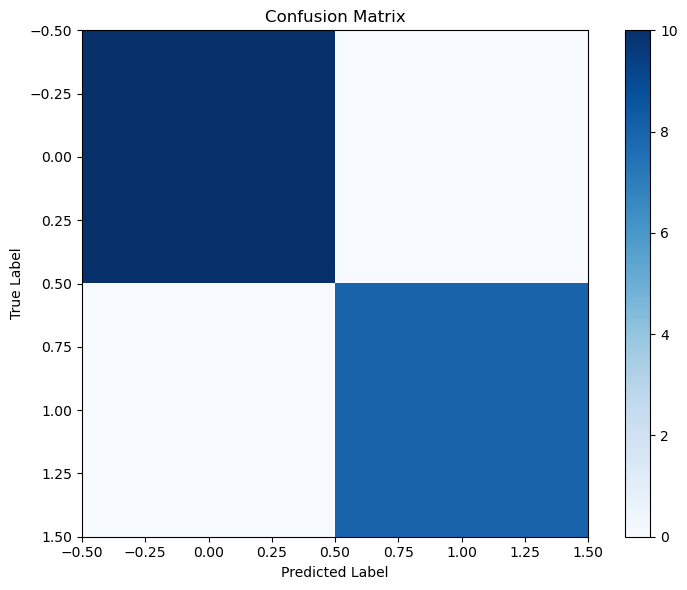

In [13]:
# plot confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

As we can see, we have a perfect accuracy. In any case, we need to have caution, since we have few test data.

# Export the model to fit it in ESP32 board 


Now we need to export the model, in order to use it in our ESP32 sensor.

In [14]:
# define an model export directory
export_dir="./model/"

# Create a directory if it does not exist
import os
if not os.path.exists(export_dir):
    os.makedirs(export_dir)


Firstly, we save the parameters used to normalize the training data, since we will use them to normalize the data during the inference:

In [15]:
# Export normalization parameters used to z-score normalize the data
# Save mean_std_min_max to a c file to be included in the ESP32 inference code
with open(export_dir+'normalization_params.h', 'w') as f:
    f.write('#include "_project_config.h"\n')
    f.write('#include <stdint.h>\n\n')
    f.write('typedef struct {\n')
    f.write('    float mean;\n')
    f.write('    float std;\n')
    f.write('    float min;\n')
    f.write('    float max;\n')
    f.write('} NormalizationParams;\n\n')
    
    f.write(f'#define NUM_FEATURES {len(feature_columns)}\n\n')

    f.write('extern NormalizationParams normalization_params[NUM_FEATURES];\n')


with open(export_dir+'normalization_params.cpp', 'w') as f:  
    f.write('#include "_project_config.h"\n')
    f.write('#include <stdint.h>\n\n')
    f.write('#include "normalization_params.h"\n\n')
      
    f.write('NormalizationParams normalization_params[NUM_FEATURES] = {\n')
    for col in feature_columns:
        mean = mean_std_min_max.at['mean', col]
        std = mean_std_min_max.at['std', col]
        min_val = mean_std_min_max.at['min', col]
        max_val = mean_std_min_max.at['max', col]
        f.write(f'    {{{mean:.6f}, {std:.6f}, {min_val:.6f}, {max_val:.6f}}}, // {col}\n')
    f.write('};\n')

Now we export the model:

In [16]:
# Create the model.h file
with open(export_dir+'model.h', 'w') as f:
    f.write('#pragma once\n\n')
    f.write('#include "_project_config.h"\n')
    f.write('#ifdef __has_attribute\n')
    f.write('#define HAVE_ATTRIBUTE(x) __has_attribute(x)\n')
    f.write('#else\n')
    f.write('#define HAVE_ATTRIBUTE(x) 0\n')
    f.write('#endif\n')
    f.write('#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))\n')
    f.write('#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))\n')
    f.write('#else\n')
    f.write('#define DATA_ALIGN_ATTRIBUTE\n')
    f.write('#endif\n\n')
    f.write('// automatically configure network\n')
    f.write('#define TF_NUM_OPS 2\n')
    f.write('#define TF_NUM_INPUTS 300\n')
    f.write('#define TF_NUM_OUTPUTS 2\n')
    f.write('#define TF_OP_FULLYCONNECTED\n')
    f.write('#define TF_OP_SOFTMAX\n\n')
    f.write('/** model size = 5048 bytes **/\n')
    f.write('extern const unsigned char __model_model_tflite[] DATA_ALIGN_ATTRIBUTE;\n')

In [17]:
# Export the trained model in TensorFlow Lite Micro format.
# Use 8-bit quantization.
tensorflite_model = tf.lite.TFLiteConverter.from_keras_model(model).convert()
with open(export_dir+'model.tflite', 'wb') as f:
   f.write(tensorflite_model)
   f.close()

# execute the following command to convert the model to a C source file:
# xxd -i model.tflite > model_data.cc
# The resulting model_data.cc file can be included in the ESP32 inference code.
!xxd.exe -i ./model/model.tflite > ./model/model.cpp


INFO:tensorflow:Assets written to: C:\Users\rrena\AppData\Local\Temp\tmpwoswk8ga\assets


INFO:tensorflow:Assets written to: C:\Users\rrena\AppData\Local\Temp\tmpwoswk8ga\assets


Saved artifact at 'C:\Users\rrena\AppData\Local\Temp\tmpwoswk8ga'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1402316256848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402316256272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402316257808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402316258768: TensorSpec(shape=(), dtype=tf.resource, name=None)


Finally we will export the training data as well, just to use it to test the exported model works in the ESP32.

In [18]:
# Save X data to a C array to be used in ESP32 to test the model
with open(export_dir+'TestData.h', 'w') as f:
    f.write('#ifndef TESTDATA_H\n')
    f.write('#define TESTDATA_H\n\n')
    
    f.write('#include "_project_config.h"\n\n')

    f.write('#ifdef __cplusplus\n')
    f.write('extern "C" {\n')
    f.write('#endif\n\n')
    
    f.write('#define NUM_TEST_SAMPLES 60\n')
    f.write('#define NUM_ITEMS_PER_SAMPLE 50\n')
    f.write('#define NUM_CHANNELS 6\n')

    f.write('#define NUM_MODEL_FEATURES 300\n\n')
    
    f.write('#ifdef __USE_INPUTSENSORTESTDATA__\n')
    f.write('extern float inputSensorData[NUM_TEST_SAMPLES][NUM_ITEMS_PER_SAMPLE][NUM_CHANNELS];\n')
    f.write('#endif\n\n')
    f.write('#ifdef __USE_MODEL_INPUT_NORMALIZED_TEST_DATA__\n')
    f.write('extern float inputTestData[NUM_TEST_SAMPLES][NUM_MODEL_FEATURES];\n')
    f.write('extern int expectedOutTestData[NUM_TEST_SAMPLES];\n')
    f.write('#endif\n\n')


    f.write('#ifdef __cplusplus\n')
    f.write('}\n')
    f.write('#endif\n\n')

    f.write('#endif // TESTDATA_H\n')
    f.close()

with open(export_dir+'TestData.cpp', 'w') as f:
    f.write('#include "_project_config.h"\n\n')
    f.write('#include "TestData.h"\n\n')        

    f.write('#ifdef __USE_INPUTSENSORTESTDATA__\n')    

    f.write('float inputSensorData[NUM_TEST_SAMPLES][NUM_ITEMS_PER_SAMPLE][NUM_CHANNELS] = {\n')
    for i in range(60):
        f.write('  {')
        for j in range(50):
            f.write('  {')
            f.write(', '.join(f'{X.iloc[i, j*6 + k]:.6f}' for k in range(6)))
            f.write('},\n')
        f.write('  },\n')
    f.write('};\n')
    f.write('#endif\n\n')

    f.write('#ifdef __USE_MODEL_INPUT_NORMALIZED_TEST_DATA__\n') 

    f.write('float inputTestData[NUM_TEST_SAMPLES][NUM_MODEL_FEATURES] = {\n')
    for index, row in X.iterrows():
        f.write('  {')
        f.write(', '.join(f'{value:.6f}' for value in row))
        f.write('},\n')
    f.write('};\n')
    f.write('int expectedOutTestData[NUM_TEST_SAMPLES] = {\n')
    for i in range(60):
        f.write(f'  {y.iloc[i]},\n')
    f.write('};\n')
    
    f.write('#endif\n\n')

    f.close()
